In [2]:
from google.colab import files
uploaded = files.upload()

Saving airbnb_clean.csv to airbnb_clean.csv


In [3]:
import pandas as pd
import numpy as np

# Učitavamo očišćeni skup podataka
df = pd.read_csv('airbnb_clean.csv')

# Idemo vidjeti kako tablica izgleda (prvih 5 redova)
df.head()

/tmp/ipykernel_9247/4242827386.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('airbnb_clean.csv')


,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
0,1001254,Clean & quiet apt home by the park,8.001449e+10,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,Private room,2020.0,966.0,193.0,10.0,9.0,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,5.233517e+10,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,Entire home/apt,2007.0,142.0,28.0,30.0,45.0,0.38,4.0,2.0,228.0
2,1002755,Water View King Bed Hotel Room,8.509833e+10,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,Entire home/apt,2005.0,368.0,74.0,30.0,270.0,4.64,4.0,1.0,322.0
3,1004650,BlissArtsSpace!,6.130061e+10,unconfirmed,Alberta,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,...,Private room,2015.0,71.0,14.0,45.0,49.0,0.40,5.0,1.0,224.0
4,1006859,Cute & Cozy Lower East Side 1 bdrm,1.280143e+09,verified,Miranda,Manhattan,Chinatown,40.71344,-73.99037,United States,...,Entire home/apt,2004.0,319.0,64.0,1.0,160.0,1.33,3.0,4.0,1.0


In [10]:
# 1. Izračun 'availability_ratio' (udio dostupnosti u godini)
df['availability_ratio'] = df['availability_365'] / 365

# 2. Izračun 'distance_to_center' (udaljenost od centra New Yorka)
# Centar New Yorka (npr. Times Square) je otprilike na koordinatama: lat = 40.7580, lon = -73.9855
# Koristimo jednostavnu formulu za udaljenost (Pitagorin poučak nad koordinatama)
lat_centar, lon_centar = 40.7580, -73.9855
df['distance_to_center'] = np.sqrt((df['lat'] - lat_centar)**2 + (df['long'] - lon_centar)**2)

# 3. Izračun 'popularity_score' (Z-score standardizacija pa zbroj)
Z_reviews = (df['number_of_reviews'] - df['number_of_reviews'].mean()) / df['number_of_reviews'].std()
Z_reviews_per_month = (df['reviews_per_month'] - df['reviews_per_month'].mean()) / df['reviews_per_month'].std()
Z_rate = (df['review_rate_number'] - df['review_rate_number'].mean()) / df['review_rate_number'].std()

df['popularity_score'] = Z_reviews + Z_reviews_per_month + Z_rate

print("Stupci su uspješno stvoreni!")
# Popis stupaca koje želimo zadržati za model
odabrani_stupci = [
    'distance_to_center', 'popularity_score', 'availability_ratio',
    'review_rate_number', 'number_of_reviews', 'minimum_nights',
    'room_type', 'neighbourhood_group', 'cancellation_policy', 'price'
]


df_model = df[odabrani_stupci].copy()

# Kratka provjera da vidimo radi li
print("Tablica df_model je uspješno stvorena!")
print("Dimenzije tablice:", df_model.shape)


Stupci su uspješno stvoreni!
Tablica df_model je uspješno stvorena!
Dimenzije tablice: (51071, 10)


In [11]:
# Popis tekstualnih stupaca koje želimo transformirati
kategorijski_stupci = ['room_type', 'neighbourhood_group', 'cancellation_policy']

# pd.get_dummies stvara stupce s 0 i 1 za svaku kategoriju
df_preuređen = pd.get_dummies(df_model, columns=kategorijski_stupci, drop_first=True)

# Idemo vidjeti kako sada izgledaju stupci i prva 3 reda
df_preuređen.head(3)

,distance_to_center,popularity_score,availability_ratio,review_rate_number,number_of_reviews,minimum_nights,price,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,cancellation_policy_moderate,cancellation_policy_strict
0,0.111287,-0.469393,0.783562,4.0,9.0,10.0,966.0,False,True,False,True,False,False,False,False,True
1,0.004709,0.322140,0.624658,4.0,45.0,30.0,142.0,False,False,False,False,True,False,False,True,False
2,0.077273,7.149631,0.882192,4.0,270.0,30.0,368.0,False,False,False,True,False,False,False,True,False


In [12]:
from sklearn.model_selection import train_test_split

# X su svi stupci OSIM cijene (price)
X = df_preuređen.drop(columns=['price'])

# y je naša cijena pretvorena u logaritam radi bolje distribucije
y = np.log1p(df_preuređen['price'])

# Dijelimo podatke na skup za učenje (train) i testiranje (test) u omjeru 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Podaci su uspješno razdvojeni i podijeljeni!")
print("Broj stanova za učenje modela:", X_train.shape[0])
print("Broj stanova za testiranje modela:", X_test.shape[0])

Podaci su uspješno razdvojeni i podijeljeni!
Broj stanova za učenje modela: 40856
Broj stanova za testiranje modela: 10215


In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

# 1. Nova definicija: X su svi stupci OSIM cijene i popularnosti
X_pop = df_preuređen.drop(columns=['price', 'popularity_score'])

# y_pop je sada naša nova ciljna varijabla - popularnost!
y_pop = df_preuređen['popularity_score']

# 2. Dijelimo podatke ponovno 80:20
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pop, y_pop, test_size=0.2, random_state=42)

# 3. Treniramo model za predviđanje popularnosti
print("Treniram model za predviđanje popularnosti smještaja...")
xgb_pop = XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.08, random_state=42)
xgb_pop.fit(X_train_p, y_train_p)

# 4. Predviđanje i metrike
y_pred_p = xgb_pop.predict(X_test_p)
r2_p = r2_score(y_test_p, y_pred_p)
mae_p = mean_absolute_error(y_test_p, y_pred_p)

print("\n--- REZULTATI MODELA ZA POPULARNOST ---")
print(f"R2 Score (Uspješnost modela): {r2_p * 100:.2f}%")
print(f"Prosječna pogreška (MAE): {mae_p:.2f}")

Treniram model za predviđanje popularnosti smještaja...

--- REZULTATI MODELA ZA POPULARNOST ---
R2 Score (Uspješnost modela): 84.83%
Prosječna pogreška (MAE): 0.36


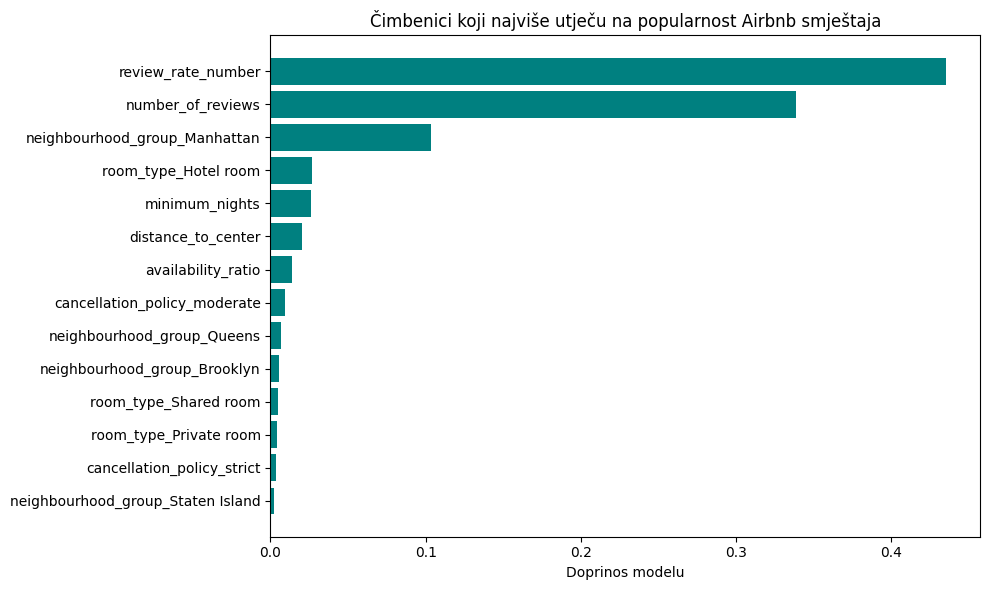

In [17]:
import matplotlib.pyplot as plt

# Izvlačimo važnost značajki iz modela
vaznost = xgb_pop.feature_importances_
značajke = X_pop.columns

# Stvaramo tablicu i sortiramo je:
df_vaznost = pd.DataFrame({'Značajka': značajke, 'Važnost': vaznost}).sort_values(by='Važnost', ascending=True)

# Crtamo grafikon
plt.figure(figsize=(10, 6))
plt.barh(df_vaznost['Značajka'], df_vaznost['Važnost'], color='teal')
plt.xlabel('Doprinos modelu')
plt.title('Čimbenici koji najviše utječu na popularnost Airbnb smještaja')
plt.tight_layout()
plt.show()